In [1]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 7.1 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.3 MB 4.9 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.3 MB 5.1 MB/s eta 0:00:02
   ------------------ --------------------- 3.9/8.3 MB 4.9 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.3 MB 4.8 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 4.9 MB/s eta 0:00:01
   ------------------------------------- -- 7.9/8.3 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 5.1 MB/s  0:00:01
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   - -------------------------------------- 1.3/37.4 MB 6.7 MB/s eta 0:00:06
   --- ------------------------------------ 2.9/37.4 MB 7.0 MB/s eta 0:00:05
   ---- ----------------------------------- 4.5/37.4 MB 7.4 MB/s eta 0:00:05
   ------ ---------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.pipeline import Pipeline,make_pipeline



In [52]:
df = pd.read_csv("housing.csv")

In [53]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [54]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [55]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

In [56]:
X = np.array(df["median_income"]).reshape(-1,1)
y = np.array(df["median_house_value"]).reshape(-1,1)

In [57]:
y.shape

(20640, 1)

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["median_house_value"]),df["median_house_value"] , test_size=0.2, random_state=42
)

In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

ValueError: could not convert string to float: 'NEAR OCEAN'

In [60]:
y_pred = model.predict(X_test)

ValueError: could not convert string to float: 'INLAND'

In [61]:
y_pred[:5]


array([[114958.91676996],
       [150606.88213964],
       [190393.71844449],
       [285059.38345102],
       [200663.31816103]])

In [62]:
y_test[:5]

20046     47700.0
3024      45800.0
15663    500001.0
20484    218600.0
9814     278000.0
Name: median_house_value, dtype: float64

In [63]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 7091157771.76555
RMSE: 84209.01241414454
R²: 0.45885918903846656


ValueError: x and y must be the same size

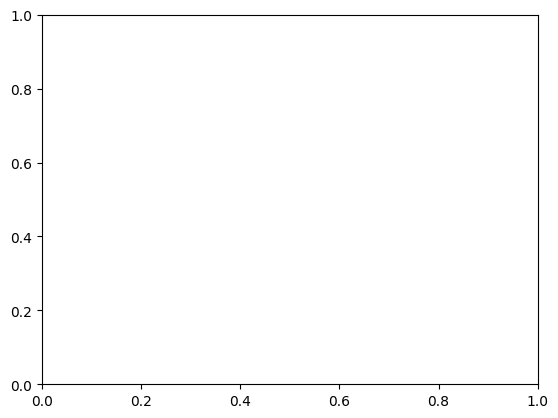

In [20]:


plt.scatter(X_test, y_test, alpha=0.1,c="r")
plt.plot(X_test, y_pred)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Linear Regression: Income vs House Value")
plt.show()

In [21]:
df.head()
df.shape

(20640, 10)

In [17]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [40]:
tr1 = ColumnTransformer([
    (
        "ocean_prox_en",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            categories=[["NEAR BAY", "INLAND"]]
        ),
        [8]
    )
], remainder="passthrough")

In [41]:
tr2 = ColumnTransformer(
    [
        ("scaling", StandardScaler(), slice(0, 8))
    ],
    remainder="passthrough"
)

In [42]:
tr3=LinearRegression()

In [43]:
pipeline = make_pipeline(
    tr1,
    tr2,
    tr3
)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["median_house_value"]),df["median_house_value"] , test_size=0.2, random_state=42
)

In [45]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer-1', ...), ('columntransformer-2', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ocean_prox_en', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automa

In [46]:
y_test=pipeline.predict(X_test)

In [47]:
y_test

array([ 54492.3915301 , 128672.25402731, 247870.04995215, ...,
       444262.16355514, 122784.60585225, 182702.10449804], shape=(4128,))

In [48]:
r2 = r2_score(y_test, y_pred)


In [49]:
r2

0.7293818605799554

ValueError: x and y must be the same size

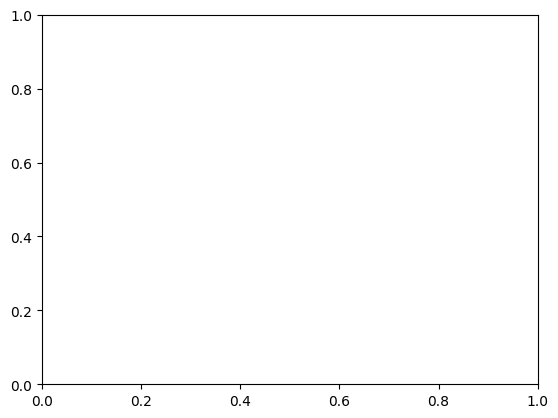

In [64]:
plt.scatter(X_test, y_test, alpha=0.1,c="r")
plt.plot(X_test, y_pred)
plt.show()

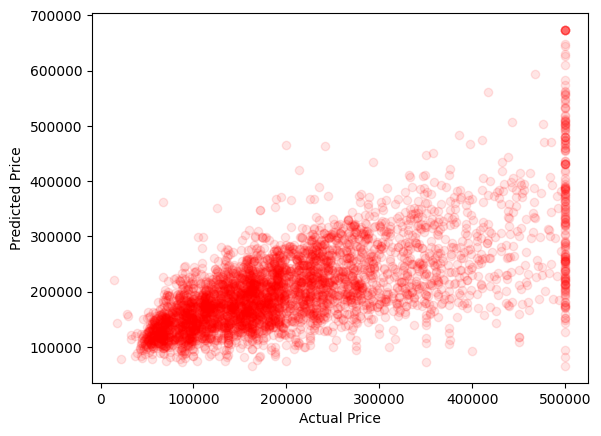

In [65]:
plt.scatter(y_test, y_pred, alpha=0.1, c="r")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()